## Objetivo do Projeto
Este projeto tem como objetivo desenvolver um modelo de **Machine Learning** capaz de prever se um usuário completará uma transação (Revenue) em um e-commerce, com base em seu comportamento de navegação.

A estratégia foca em:
1.  **Análise Exploratória (EDA):** Identificar gatilhos que levam à conversão e comportamentos que indicam abandono.
2.  **Modelagem Preditiva:** Comparar algoritmos clássicos (Regressão Logística),  RandomForestClassifier, Boosting (XGBoost) e Deep Learning para encontrar a melhor performance.
3.  **Otimização:** Utilizar o **Optuna** para ajuste fino de hiperparâmetros, priorizando o **Recall** para minimizar a perda de oportunidades de venda.
4.  **Explicabilidade (SHAP):** Interpretar as decisões do modelo para fornecer insights acionáveis ao time de Marketing.

## Dataset utilizado:
[Online Shoppers Purchasing Intention Dataset](https://www.kaggle.com/datasets/imakash3011/online-shoppers-purchasing-intention-dataset?select=online_shoppers_intention.csv)

##Bibliotecas instaladas

In [2]:
!pip install dvc
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.7/375

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.8 MB/s eta 0:00:00


In [4]:
!pip install shap

##Bibliotecas utilizadas

In [20]:
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import dvc
import mlflow
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.tensorflow
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Recall
import optuna
import shap
from google.colab import files


##Carregando Dataset

In [10]:
df = pd.read_csv('online_shoppers_intention.csv')

##Adiciona o dataset original ao DVC

In [5]:
!dvc init --no-scm -f
!dvc add online_shoppers_intention.csv

Initialized DVC repository.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>
⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Adding online_shoppers_intention.csv to cache:

##Análise Exploratória (EDA)

In [6]:
#verificando dados nulos
df.isna().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [7]:
# verificando colunas do dataset
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [8]:
# verificando tipos de dados do dataset
df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [9]:
# verificando estatisticas basicas do dataset
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [10]:
# verificando dados do dataset
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


Identifiquei que datas especiais geram muito tráfego, mas baixo engajamento de compra. Os usuários usam o site como 'vitrine' para comparar preços, mas provavelmente compram na concorrência ou em lojas físicas. O Marketing deveria focar campanhas de retenção nesses dias.

Dias normais (0.0) têm uma conversão de 16.5%. Mas conforme a data comemorativa se aproxima (0.8 ou 1.0), a conversão despenca para 3% a 6%.

In [11]:
taxa_conversao_por_data = df.groupby('SpecialDay')['Revenue'].mean() * 100

print("Taxa de Conversão por Proximidade de Data Especial (%):")
print(taxa_conversao_por_data)

Taxa de Conversão por Proximidade de Data Especial (%):
SpecialDay
0.0    16.526762
0.2     7.865169
0.4     5.349794
0.6     8.262108
0.8     3.384615
1.0     6.493506
Name: Revenue, dtype: float64


A intuição inicial era de que as datas especiais trariam a maior conversão, mas a Análise Exploratória revelou que o comportamento real do usuário depende do Valor da Página, quanto maior o valor, maior a taxa de conversão

In [12]:
taxa_conversao_por_valor_da_pagina = df.groupby('PageValues')['Revenue'].mean() * 100
print("Taxa de Conversão por Valor da Página (%):")
print(taxa_conversao_por_valor_da_pagina)

Taxa de Conversão por Valor da Página (%):
PageValues
0.000000        3.854167
0.038035        0.000000
0.067050      100.000000
0.093547      100.000000
0.098621      100.000000
                 ...    
261.491286    100.000000
270.784693    100.000000
287.953793    100.000000
360.953384    100.000000
361.763742    100.000000
Name: Revenue, Length: 2704, dtype: float64


Ficar muito tempo na página poderia significar que o cliente adorou o produto, mas também pode significar que ele deixou a aba do navegador aberta e foi almoçar, portanto não garante aumento da Taxa de Conversão!

In [13]:
taxa_conversao_por_tempo_na_pagina_produto = df.groupby('ProductRelated_Duration')['Revenue'].mean() * 100
print("Taxa de Conversão por Tempo Gasto na Página do Produto (%):")
print(taxa_conversao_por_tempo_na_pagina_produto)

Taxa de Conversão por Tempo Gasto na Página do Produto (%):
ProductRelated_Duration
0.000000          1.721854
0.500000          0.000000
1.000000          0.000000
2.333333          0.000000
2.666667          0.000000
                   ...    
24844.156200      0.000000
27009.859430    100.000000
29970.465970      0.000000
43171.233380      0.000000
63973.522230      0.000000
Name: Revenue, Length: 9551, dtype: float64


##Teste de Hipóteses
Utilizaremos 5% como valor de significância

### Hipótese 1:

**H0 (Hipótese Nula):** Não há diferença significativa entre a taxa de conversão de clientes recorrentes e novos visitantes.

**H1:** Clientes recorrentes (`Returning_Visitor`) possuem uma taxa de conversão (vendas) significativamente maior do que clientes novos (`New_Visitor`).

In [14]:
tabela_contingencia = pd.crosstab(df['VisitorType'], df['Revenue'])
chi2, p_valor, dof, expected = chi2_contingency(tabela_contingencia)

print("Tabela de Contingência:")
print(tabela_contingencia)
print(f"p-valor: {p_valor}")
if p_valor < 0.05:
    print("Hipótese nula rejeitada. Há uma diferença significativa entre as taxas de conversão de clientes recorrentes e novos visitantes.")

Tabela de Contingência:
Revenue            False  True 
VisitorType                    
New_Visitor         1272    422
Other                 69     16
Returning_Visitor   9081   1470
p-valor: 4.269904152293867e-30
Hipótese nula rejeitada. Há uma diferença significativa entre as taxas de conversão de clientes recorrentes e novos visitantes.


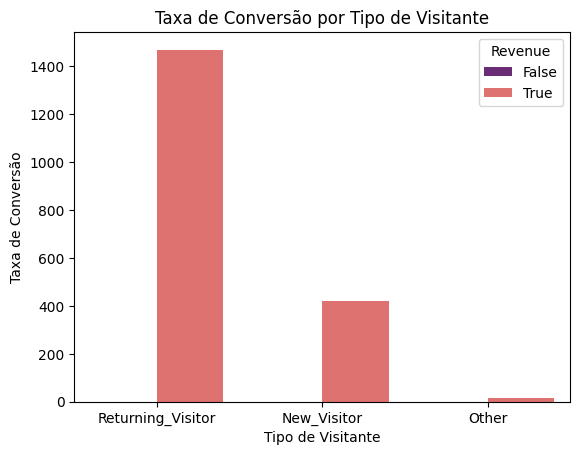

In [15]:
sns.barplot(x='VisitorType', y='Revenue', data=df, estimator=sum, palette='magma', hue='Revenue')
plt.title('Taxa de Conversão por Tipo de Visitante')
plt.xlabel('Tipo de Visitante')
plt.ylabel('Taxa de Conversão')
plt.show()

### Hipótese 2:

**H0 (Hipótese Nula):** A taxa de conversão nos finais de semana é igual ou superior à taxa de conversão nos dias úteis.

**H1:** As taxas de conversão caem nos finais de semana (`Weekend = True`), pois os usuários usam o tempo livre apenas para pesquisar.

In [16]:
tabela_contingencia = pd.crosstab(df['Weekend'], df['Revenue'])
chi2, p_valor, dof, expected = chi2_contingency(tabela_contingencia)

print("Tabela de Contingência:")
print(tabela_contingencia)
print(f"p-valor: {p_valor}")
if p_valor < 0.05:
    print("Hipótese nula rejeitada. As taxas de conversão caem nos finais de semana.")

Tabela de Contingência:
Revenue  False  True 
Weekend              
False     8053   1409
True      2369    499
p-valor: 0.0012663251061221968
Hipótese nula rejeitada. As taxas de conversão caem nos finais de semana.


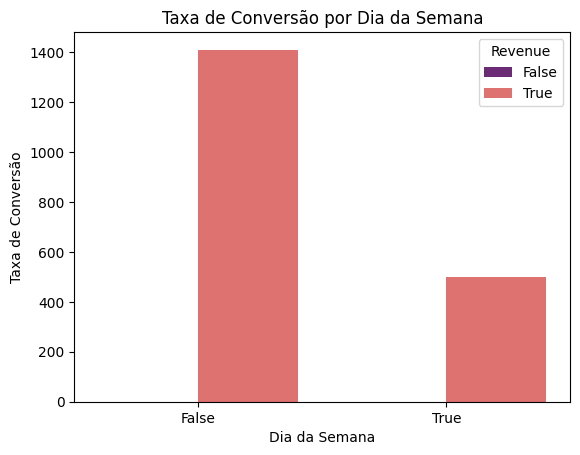

In [17]:
sns.barplot(x='Weekend', y='Revenue', data=df, estimator=sum, palette='magma', hue='Revenue')
plt.title('Taxa de Conversão por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Taxa de Conversão')
plt.show()

### Hipótese 3:

**H0 (Hipótese Nula):** A taxa de conversão no mês de Novembro é igual ou inferior à média da taxa de conversão dos outros meses do ano.

**H1:** O mês de Novembro (`Month = 'Nov'`) possui uma taxa de conversão significativamente maior que a dos outros meses.

In [18]:
tabela_contingencia = pd.crosstab(df['Month'], df['Revenue'])
chi2, p_valor, dof, expected = chi2_contingency(tabela_contingencia)

print("Tabela de Contingência:")
print(tabela_contingencia)
print(f"p-valor: {p_valor}")
if p_valor < 0.05:
    print("Hipótese nula rejeitada. O mês de Novembro possui uma taxa de conversão significativamente maior que a dos outros meses.")

Tabela de Contingência:
Revenue  False  True 
Month                
Aug        357     76
Dec       1511    216
Feb        181      3
Jul        366     66
June       259     29
Mar       1715    192
May       2999    365
Nov       2238    760
Oct        434    115
Sep        362     86
p-valor: 2.2387855164805443e-77
Hipótese nula rejeitada. O mês de Novembro possui uma taxa de conversão significativamente maior que a dos outros meses.


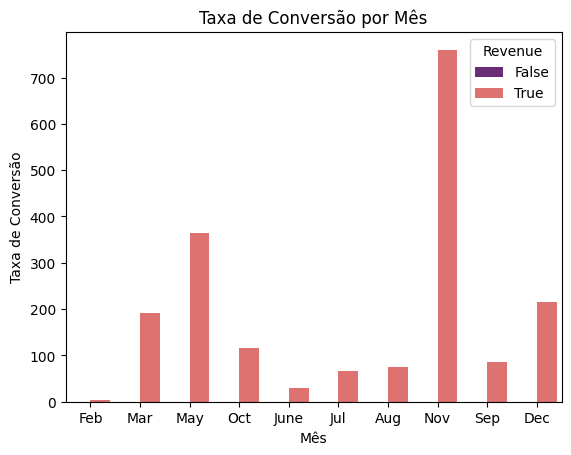

In [19]:
sns.barplot(x='Month', y='Revenue', data=df, estimator=sum, palette='magma', hue='Revenue')
plt.title('Taxa de Conversão por Mês')
plt.xlabel('Mês')
plt.ylabel('Taxa de Conversão')
plt.show()

##Feature engineering

In [11]:
# convertendo dados pra int
df['Revenue'] = df['Revenue'].astype(int)
df['Weekend'] = df['Weekend'].astype(int)

# criando a duracao total e total de paginas visitadas
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']
df['Total_Pages_Visited'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

# criando a media de tempo por pagina
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Total_Pages_Visited'] + 1)

# removendo colunas que nao serao utilizadas no modelo
colunas_para_remover = ['Administrative', 'Administrative_Duration', 'Informational',
                        'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration']
df = df.drop(columns=colunas_para_remover)

# transformando meses em numeros mantendo a ordem
meses_ordem = {'Feb':2, 'Mar':3, 'May':5, 'June':6, 'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}
df['Month'] = df['Month'].map(meses_ordem)

# usando OneHotEncoding na coluna 'VisitorType'
df = pd.get_dummies(df, columns=['VisitorType'], drop_first=True)

In [21]:
df.head()

,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Total_Duration,Total_Pages_Visited,Avg_Time_Per_Page,VisitorType_Other,VisitorType_Returning_Visitor
0,0.20,0.20,0.0,0.0,2,1,1,1,1,0,0,0.000000,1,0.000000,False,True
1,0.00,0.10,0.0,0.0,2,2,2,1,2,0,0,64.000000,2,21.333333,False,True
2,0.20,0.20,0.0,0.0,2,4,1,9,3,0,0,0.000000,1,0.000000,False,True
3,0.05,0.14,0.0,0.0,2,3,2,2,4,0,0,2.666667,2,0.888889,False,True
4,0.02,0.05,0.0,0.0,2,3,3,1,4,1,0,627.500000,10,57.045455,False,True


In [22]:
# verificando outliers
df.describe()

,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Total_Duration,Total_Pages_Visited,Avg_Time_Per_Page
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,0.022191,0.043073,5.889258,0.061427,7.651987,2.124006,2.357097,3.147364,4.069586,0.232603,0.154745,1310.037228,34.550203,34.790387
std,0.048488,0.048597,18.568437,0.198917,3.392841,0.911325,1.717277,2.401591,4.025169,0.422509,0.361676,2037.801702,46.514053,33.850108
min,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.014286,0.000000,0.000000,5.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000,222.000000,8.000000,16.843155
50%,0.003112,0.025156,0.000000,0.000000,7.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000,680.000000,20.000000,27.970982
75%,0.016813,0.050000,0.000000,0.000000,11.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000,1626.908333,42.000000,43.118423
max,0.200000,0.200000,361.763742,1.000000,12.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000,69921.647230,746.000000,940.666667


## Limpeza e tratamento dos dados

In [12]:
# removendo outliers da coluna Total_Duration para excluir quem esqueceu a pagina aberta, gerando um valor muito alto sem converter em compra
coluna_alvo = 'Total_Duration'

Q1 = df[coluna_alvo].quantile(0.25)
Q3 = df[coluna_alvo].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# filtrando outliers
df_sem_outliers = df[(df[coluna_alvo] >= limite_inferior) & (df[coluna_alvo] <= limite_superior)]

print(f'Tamanho original: {len(df)}')
print(f'Tamanho após remover outliers de {coluna_alvo}: {len(df_sem_outliers)}')
display(df_sem_outliers.head())

Tamanho original: 12330
Tamanho após remover outliers de Total_Duration: 11394


,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Total_Duration,Total_Pages_Visited,Avg_Time_Per_Page,VisitorType_Other,VisitorType_Returning_Visitor
0,0.20,0.20,0.0,0.0,2,1,1,1,1,0,0,0.000000,1,0.000000,False,True
1,0.00,0.10,0.0,0.0,2,2,2,1,2,0,0,64.000000,2,21.333333,False,True
2,0.20,0.20,0.0,0.0,2,4,1,9,3,0,0,0.000000,1,0.000000,False,True
3,0.05,0.14,0.0,0.0,2,3,2,2,4,0,0,2.666667,2,0.888889,False,True
4,0.02,0.05,0.0,0.0,2,3,3,1,4,1,0,627.500000,10,57.045455,False,True


In [24]:
# verificando outliers removidos da coluna 'Total_Duration'
display(df_sem_outliers.describe())

,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Total_Duration,Total_Pages_Visited,Avg_Time_Per_Page
count,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000,11394.000000
mean,0.023472,0.044903,5.785624,0.062823,7.535808,2.122872,2.356416,3.166842,4.107337,0.233105,0.142707,886.133700,25.680885,33.156037
std,0.050176,0.049974,18.650799,0.200542,3.403004,0.926320,1.731863,2.406066,4.042799,0.422827,0.349789,875.832880,25.093015,33.528388
min,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.014286,0.000000,0.000000,5.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000,196.575000,8.000000,16.004793
50%,0.002572,0.026667,0.000000,0.000000,7.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000,594.733333,18.000000,26.434611
75%,0.018182,0.050000,0.000000,0.000000,11.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000,1324.654167,36.000000,41.069876
max,0.200000,0.200000,361.763742,1.000000,12.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000,3733.228571,258.000000,940.666667


##Feature selection usando matriz de correlação

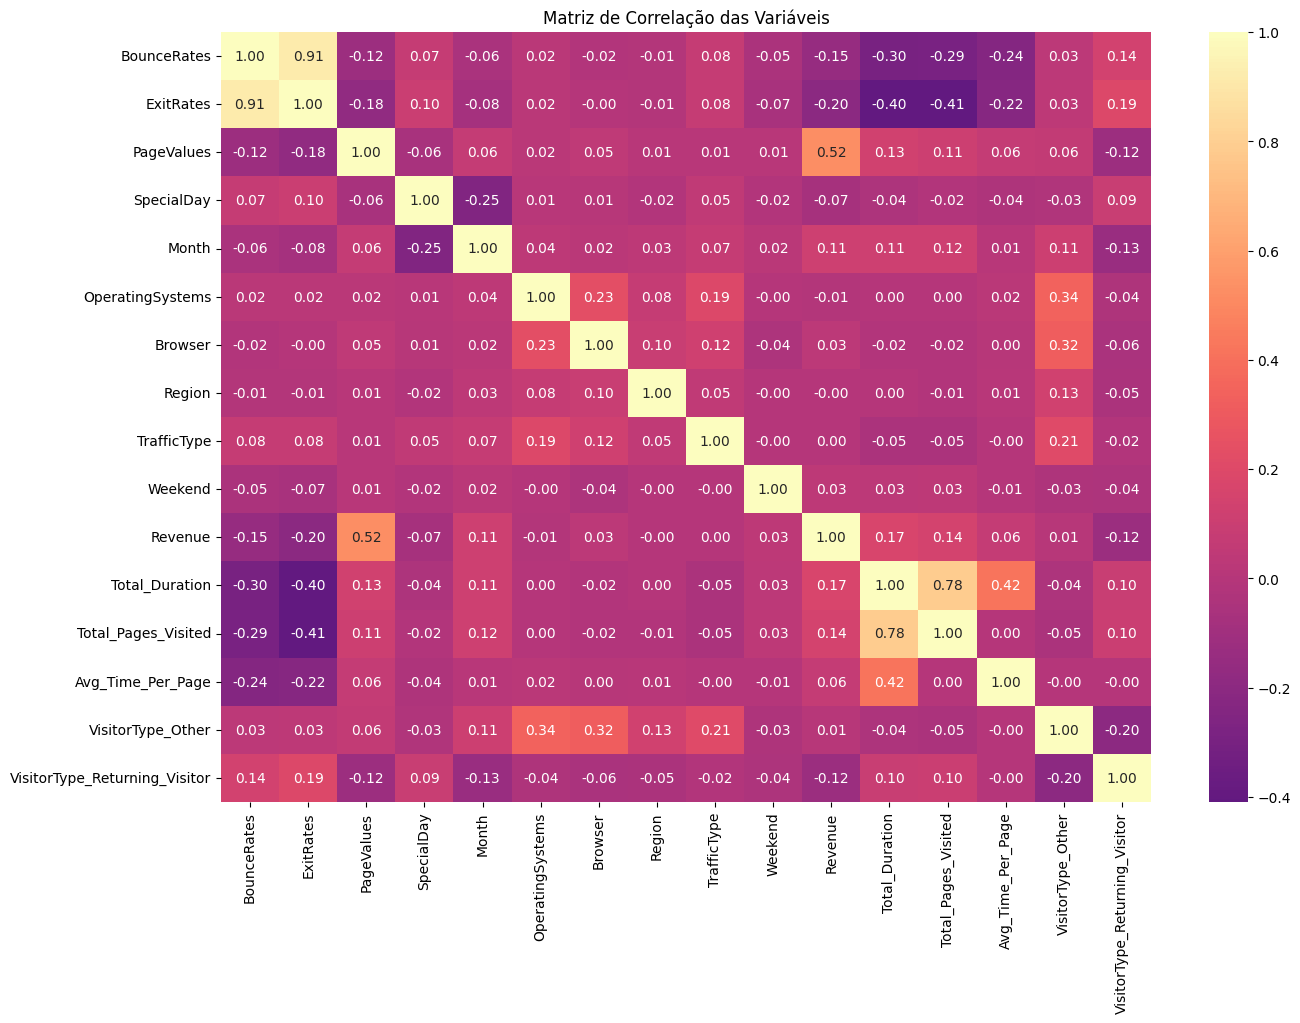

In [25]:
# calculando a matriz de correlação
plt.figure(figsize=(15, 10))
correlation_matrix = df_sem_outliers.corr()

# criando um heatmap pra visualizar
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='magma', center=0)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

* Correlação entre 'Total_Duration' e 'Total_Pages_Visited' é alta, 0.78, podemos manter apenas Total_Duration para evitar a multicolinearidade, o mesmo acontece com 'Avg_Time_Per_Page' e 'Total_Duration'

* O mesmo acontece entre 'ExitRates' e 'BounceRates'

In [26]:
# filtrando as correlações mais fortes com o Revenue (nosso alvo)
corr_with_revenue = correlation_matrix['Revenue'].sort_values(ascending=False)
print("Correlação das features com a variável Alvo (Revenue):")
print(corr_with_revenue)

Correlação das features com a variável Alvo (Revenue):
Revenue                          1.000000
PageValues                       0.523296
Total_Duration                   0.171883
Total_Pages_Visited              0.141710
Month                            0.108969
Avg_Time_Per_Page                0.064818
Weekend                          0.032030
Browser                          0.028177
VisitorType_Other                0.006822
TrafficType                      0.001457
Region                          -0.003367
OperatingSystems                -0.012404
SpecialDay                      -0.074513
VisitorType_Returning_Visitor   -0.123035
BounceRates                     -0.149311
ExitRates                       -0.203312
Name: Revenue, dtype: float64


* 'PageValues' tem a maior correlação positiva com nosso alvo 'Revenue'

* 'ExitRates' tem a maior correlação negativa (quanto mais o usuário sai rápido, menos ele compra)

* 'Month': Alguns meses, especialmente novembro como verificamos anteriormente, possuem uma taxa de conversão significativamente maior que a dos outros meses.

* O tipo de visitante afeta a conversão positivamente e negativamente, incluiremos 'VisitorType_Returning_Visitor' e 'VisitorType_Other '

### Seleção de Features (Evitando a Maldição da Dimensionalidade)

Para evitar o sobreajuste e a complexidade desnecessária, selecionamos apenas 6 preditores que não são redundantes entre si.

In [13]:
features_selecionadas = [
    'PageValues',
    'ExitRates',
    'Total_Duration',
    'Month',
    'VisitorType_Returning_Visitor',
    'VisitorType_Other',
    'Revenue'
]

df_modelagem = df_sem_outliers[features_selecionadas].copy()

print(f"Dataset otimizado: {df_modelagem.shape[0]} amostras e apenas {df_modelagem.shape[1]-1} preditores.")
display(df_modelagem.head())

Dataset otimizado: 11394 amostras e apenas 6 preditores.


,PageValues,ExitRates,Total_Duration,Month,VisitorType_Returning_Visitor,VisitorType_Other,Revenue
0,0.0,0.20,0.000000,2,True,False,0
1,0.0,0.10,64.000000,2,True,False,0
2,0.0,0.20,0.000000,2,True,False,0
3,0.0,0.14,2.666667,2,True,False,0
4,0.0,0.05,627.500000,2,True,False,0


##Separando os dados (Treino, Validação, Teste)

In [14]:
# definindo X: features e y: Alvo
X = df_modelagem.drop('Revenue', axis=1)
y = df_modelagem['Revenue']

In [15]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

In [16]:
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, stratify=y_temp, random_state=42)

##Normalizando dados

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [32]:
print(f"Treino: {X_train_scaled.shape}")
print(f"Validação: {X_val_scaled.shape}")
print(f"Teste: {X_test_scaled.shape}")

Treino: (7975, 6)
Validação: (1709, 6)
Teste: (1710, 6)


##Modelos Base (Baselines)

In [33]:
# ativando o autolog do MLflow para TensorFlow (captura épocas, loss, etc)
mlflow.tensorflow.autolog()

# definindo os modelos
modelos = {
    "Logistic_Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "Random_Forest": RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(scale_pos_weight=5, random_state=42, eval_metric='logloss')
}

In [34]:
# nome do experimento
mlflow.set_experiment("Ecommerce_Revenue")

# testando modelos clássicos
for nome, modelo in modelos.items():
    with mlflow.start_run(run_name=f"Baseline_{nome}"):

        # treinamento
        modelo.fit(X_train_scaled, y_train)

        # previsão na validação
        y_pred = modelo.predict(X_val_scaled)
        y_prob = modelo.predict_proba(X_val_scaled)[:, 1] if hasattr(modelo, "predict_proba") else y_pred

        # métricas
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)

        # logando métricas
        mlflow.log_metrics({"val_accuracy": acc, "val_precision": prec, "val_recall": rec, "val_roc_auc": auc})

        if nome == "XGBoost":
            mlflow.xgboost.log_model(modelo, name=f"model_{nome}")
        else:
            mlflow.sklearn.log_model(modelo, name=f"model_{nome}")

        print(f"✅ {nome} treinado. AUC-ROC: {auc:.4f} | Recall: {rec:.4f} | Acurácia: {acc:.4f} | Precisão: {prec:.4f}")

2026/05/11 21:32:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/11 21:32:58 INFO mlflow.store.db.utils: Updating database tables
2026/05/11 21:33:01 INFO mlflow.tracking.fluent: Experiment with name 'Ecommerce_Revenue' does not exist. Creating a new experiment.
2026/05/11 21:33:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logistic_Regression treinado. AUC-ROC: 0.9044 | Recall: 0.7049 | Acurácia: 0.8929 | Precisão: 0.6078


2026/05/11 21:33:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random_Forest treinado. AUC-ROC: 0.8969 | Recall: 0.5656 | Acurácia: 0.9029 | Precisão: 0.6970
✅ XGBoost treinado. AUC-ROC: 0.9134 | Recall: 0.6475 | Acurácia: 0.8888 | Precisão: 0.6031


## Métricas obtidas
* Logistic_Regression: AUC-ROC: 0.9044 | Recall: 0.7049 | Acurácia: 0.8929 | Precisão: 0.6078

* Random_Forest: AUC-ROC: 0.8969 | Recall: 0.5656 | Acurácia: 0.9029 | Precisão: 0.6970

* XGBoost: AUC-ROC: 0.9134 | Recall: 0.6475 | Acurácia: 0.8888 | Precisão: 0.6031

In [35]:
# iniciando experimento com deep learning
with mlflow.start_run(run_name="Baseline_DeepLearning"):

    # arquitetura da rede neural
    nn_model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Recall(name='recall')])

    # early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # treinamento
    nn_model.fit(X_train_scaled, y_train.values,
                 validation_data=(X_val_scaled, y_val.values),
                 epochs=50,
                 batch_size=32,
                 callbacks=[early_stop],
                 class_weight={0: 1, 1: 5},
                 verbose=0)

    y_prob_nn = nn_model.predict(X_val_scaled)
    y_pred_nn = (y_prob_nn > 0.5).astype(int)

    auc_nn = roc_auc_score(y_val, y_prob_nn)
    rec_nn = recall_score(y_val, y_pred_nn)
    acc_nn = accuracy_score(y_val, y_pred_nn)
    prec_nn = precision_score(y_val, y_pred_nn, zero_division=0)

    # logando métricas
    mlflow.log_metrics({"val_roc_auc_final": auc_nn, "val_recall_final": rec_nn, "val_accuracy_final": acc_nn, "val_precision_final": prec_nn})

    # salvando o modelo manualmente
    mlflow.keras.log_model(nn_model, name="modelo_base_dl")

    print(f"✅ Deep Learning treinado. AUC-ROC: {auc_nn:.4f} | Recall: {rec_nn:.4f} | Acurácia: {acc_nn:.4f} | Precisão: {prec_nn:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


2026/05/11 21:33:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


2026/05/11 21:34:01 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


✅ Deep Learning treinado. AUC-ROC: 0.9175 | Recall: 0.7131 | Acurácia: 0.8976 | Precisão: 0.6237


Deep Learning: AUC-ROC: 0.9175 | Recall: 0.7131 | Acurácia: 0.8976 | Precisão: 0.6237

## Comparação dos Modelos Base (Baselines)

Comparamos o desempenho dos quatro modelos antes de qualquer otimização.

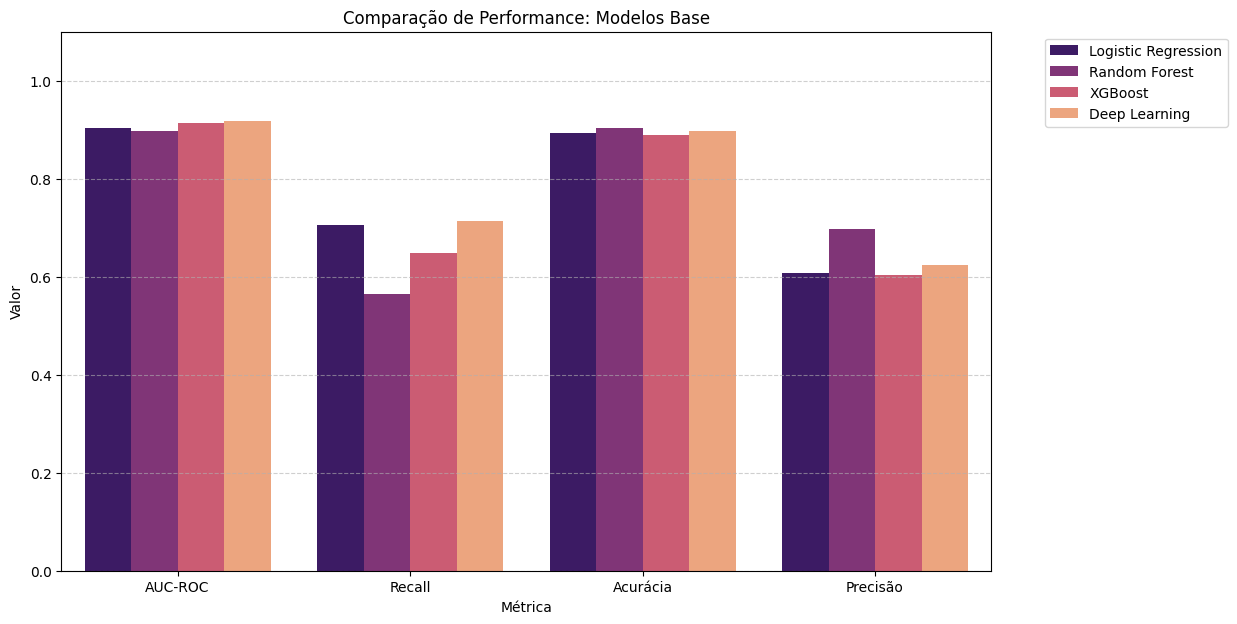

,Modelo,AUC-ROC,Recall,Acurácia,Precisão
0,Logistic Regression,0.904400,0.704900,0.892900,0.607800
1,Random Forest,0.896900,0.565600,0.902900,0.697000
2,XGBoost,0.913400,0.647500,0.888800,0.603100
3,Deep Learning,0.917484,0.713115,0.897601,0.623656


In [36]:
resultados_base = {
    'Modelo': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Deep Learning'],
    'AUC-ROC': [0.9044, 0.8969, 0.9134, auc_nn],
    'Recall': [0.7049, 0.5656, 0.6475, rec_nn],
    'Acurácia': [0.8929, 0.9029, 0.8888, acc_nn],
    'Precisão': [0.6078, 0.6970, 0.6031, prec_nn]
}

df_comparacao = pd.DataFrame(resultados_base)
df_melted = df_comparacao.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted, x='Métrica', y='Valor', hue='Modelo', palette='magma')
plt.title('Comparação de Performance: Modelos Base')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

display(df_comparacao)

###Comparação dos Modelos Base:

* XGBoost: Foi o campeão inicial em AUC-ROC (0.9134). Ele lida muito bem com dados tabulares e tem parâmetros poderosos para tratar o desequilíbrio de classes.

* Logistic Regression: Apesar de simples, teve o melhor Recall inicial (0.7049) entre os modelos clássicos, o que é vital para não perder vendas potenciais.

* Deep Learning: Surpreendeu com o melhor AUC-ROC (0.917484) e Recall (0.713115) logo de 'cara', mostrando que a rede neural captou padrões complexos que os outros não viram.

* Random Forest: Embora robusto, teve o pior Recall (0.5656). Como nosso foco é identificar compradores, ele acabou sendo o elo mais fraco.

Seguimos com o XGBoost e Regressão Logística para o Optuna porque eles representam o melhor dos dois mundos: um é altamente complexo/preciso e o outro é simples/interpretável com ótimo Recall. O Deep Learning foi mantido como nosso 'benchmark' de alta performance para desafiar os modelos tunados, além de ser tunado também.

## Otimizando com Optuna

### Otimizando XGBoost

In [37]:
# função objetivo que o Optuna vai tentar maximizar
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 3.0, 7.0),
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    modelo = XGBClassifier(**param)
    modelo.fit(X_train_scaled, y_train)

    # avaliando na Validação
    y_prob = modelo.predict_proba(X_val_scaled)[:, 1]
    auc = roc_auc_score(y_val, y_prob)
    return auc

print("Otimizando XGBoost...")

# executa o Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("Melhores hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# treinando modelo final e obtendo metricas
with mlflow.start_run(run_name="XGBoost_Optuna_Tuned"):

    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['eval_metric'] = 'logloss'

    # treina o campeão
    campeao_xgb = XGBClassifier(**best_params)
    campeao_xgb.fit(X_train_scaled, y_train)

    # previsões
    y_pred = campeao_xgb.predict(X_val_scaled)
    y_prob = campeao_xgb.predict_proba(X_val_scaled)[:, 1]

    # calculando todas as métricas explicitamente
    auc_final = roc_auc_score(y_val, y_prob)
    acc_final = accuracy_score(y_val, y_pred)
    prec_final = precision_score(y_val, y_pred, zero_division=0)
    rec_final = recall_score(y_val, y_pred)

    # logando no MLflow
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        "final_val_auc": auc_final,
        "final_val_accuracy": acc_final,
        "final_val_precision": prec_final,
        "final_val_recall": rec_final
    })
    mlflow.xgboost.log_model(campeao_xgb, name="xgboost_tunado")

    print('Métricas finais:')
    print(f"AUC-ROC: {auc_final:.4f}, Acurácia: {acc_final:.4f}, Precisão: {prec_final:.4f}, Recall: {rec_final:.4f}")

Otimizando XGBoost...


[I 2026-05-11 21:34:12,207] A new study created in memory with name: no-name-d6d60667-690f-4f47-835f-3212562b60d9
[I 2026-05-11 21:34:12,416] Trial 0 finished with value: 0.9248992894309852 and parameters: {'n_estimators': 201, 'max_depth': 5, 'learning_rate': 0.024753165512107878, 'subsample': 0.6413448738524904, 'colsample_bytree': 0.770992302688729, 'scale_pos_weight': 5.286117631129356}. Best is trial 0 with value: 0.9248992894309852.
[I 2026-05-11 21:34:12,702] Trial 1 finished with value: 0.9202624069825995 and parameters: {'n_estimators': 156, 'max_depth': 9, 'learning_rate': 0.03599877946287679, 'subsample': 0.7437712364956108, 'colsample_bytree': 0.7825914119596421, 'scale_pos_weight': 5.474030018715913}. Best is trial 0 with value: 0.9248992894309852.
[I 2026-05-11 21:34:13,213] Trial 2 finished with value: 0.8999020869467915 and parameters: {'n_estimators': 492, 'max_depth': 6, 'learning_rate': 0.2395033312094628, 'subsample': 0.6861681364349711, 'colsample_bytree': 0.862633

Melhores hiperparâmetros encontrados:
  n_estimators: 351
  max_depth: 3
  learning_rate: 0.029547371690780887
  subsample: 0.6106052495767444
  colsample_bytree: 0.997264409676238
  scale_pos_weight: 5.962529605943226
Métricas finais:
AUC-ROC: 0.9265, Acurácia: 0.8836, Precisão: 0.5688, Recall: 0.7623


###Métricas finais - XGBoost:
AUC-ROC: 0.9265, Acurácia: 0.8836, Precisão: 0.5688, Recall: 0.7623

### Otimizando Regressão Logística

In [38]:
def objective_lr(trial):
    param = {
        'C': trial.suggest_float('C', 1e-5, 100, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
        'max_iter': 1000,
        'class_weight': 'balanced',
        'random_state': 42
    }

    modelo = LogisticRegression(**param)
    modelo.fit(X_train_scaled, y_train)

    y_prob = modelo.predict_proba(X_val_scaled)[:, 1]
    auc = roc_auc_score(y_val, y_prob)
    return auc

print("Otimizando Regressão Logística...")
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=15)

# treinando o modelo final com os melhores parâmetros e logando no MLflow
with mlflow.start_run(run_name="LogisticRegression_Optuna_Tuned"):
    best_params_lr = study_lr.best_params
    best_params_lr['max_iter'] = 1000
    best_params_lr['class_weight'] = 'balanced'
    best_params_lr['random_state'] = 42

    campeao_lr = LogisticRegression(**best_params_lr)
    campeao_lr.fit(X_train_scaled, y_train)

    # previsões para cálculo de métricas
    y_pred_lr = campeao_lr.predict(X_val_scaled)
    y_prob_lr = campeao_lr.predict_proba(X_val_scaled)[:, 1]

    # calculando métricas
    auc_lr = roc_auc_score(y_val, y_prob_lr)
    acc_lr = accuracy_score(y_val, y_pred_lr)
    prec_lr = precision_score(y_val, y_pred_lr, zero_division=0)
    rec_lr = recall_score(y_val, y_pred_lr)

    # logando no MLflow
    mlflow.log_params(best_params_lr)
    mlflow.log_metrics({
        "final_val_auc": auc_lr,
        "final_val_accuracy": acc_lr,
        "final_val_precision": prec_lr,
        "final_val_recall": rec_lr
    })
    mlflow.sklearn.log_model(campeao_lr, name="logistic_regression_tunada")

    print('\nMétricas finais:')
    print(f"AUC-ROC: {auc_lr:.4f}, Acurácia: {acc_lr:.4f}, Precisão: {prec_lr:.4f}, Recall: {rec_lr:.4f}")

Otimizando Regressão Logística...


[I 2026-05-11 21:34:24,676] A new study created in memory with name: no-name-3667e07d-bb8e-4795-9ac5-884010386153
[I 2026-05-11 21:34:24,691] Trial 0 finished with value: 0.8947238851899514 and parameters: {'C': 0.0015353421099027669, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.8947238851899514.
[I 2026-05-11 21:34:24,710] Trial 1 finished with value: 0.904316566888603 and parameters: {'C': 0.34385469195051793, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.904316566888603.
[I 2026-05-11 21:34:24,725] Trial 2 finished with value: 0.89152912213954 and parameters: {'C': 0.00066929248804744, 'solver': 'liblinear'}. Best is trial 1 with value: 0.904316566888603.
[I 2026-05-11 21:34:24,744] Trial 3 finished with value: 0.9044452526156772 and parameters: {'C': 5.6196741870402205, 'solver': 'lbfgs'}. Best is trial 3 with value: 0.9044452526156772.
[I 2026-05-11 21:34:24,757] Trial 4 finished with value: 0.889573658591171 and parameters: {'C': 0.0004423308008385707, 'solver': 'libline


Métricas finais:
AUC-ROC: 0.9044, Acurácia: 0.8929, Precisão: 0.6078, Recall: 0.7049


###Métricas finais - Regressão Logística:
AUC-ROC: 0.9044, Acurácia: 0.8929, Precisão: 0.6078, Recall: 0.7049

## Otimizando Deep Learning

In [39]:
def objective_nn(trial):
    # Iniciando uma run aninhada no MLflow para cada tentativa do Optuna
    with mlflow.start_run(run_name=f"Trial_{trial.number}", nested=True):
        # Sugestão de hiperparâmetros
        n_layers = trial.suggest_int('n_layers', 2, 5)
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        weight_pos = trial.suggest_float('class_weight_pos', 3.0, 10.0)

        model = Sequential()
        model.add(Input(shape=(X_train_scaled.shape[1],)))

        for i in range(n_layers):
            num_units = trial.suggest_int(f'n_units_l{i}', 16, 256, log=True)
            dropout_rate = trial.suggest_float(f'dropout_l{i}', 0.1, 0.5)
            model.add(Dense(num_units, activation='relu'))
            model.add(Dropout(dropout_rate))

        model.add(Dense(1, activation='sigmoid'))

        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.fit(X_train_scaled, y_train.values,
                  validation_data=(X_val_scaled, y_val.values),
                  epochs=30,
                  batch_size=32,
                  callbacks=[early_stop],
                  class_weight={0: 1, 1: weight_pos},
                  verbose=0)

        # Avaliando o AUC-ROC no conjunto de validação
        y_prob = model.predict(X_val_scaled, verbose=0)
        auc = roc_auc_score(y_val, y_prob)

        # Logando parâmetros e métrica da tentativa atual no MLflow
        mlflow.log_params(trial.params)
        mlflow.log_metric("auc_roc", auc)

        return auc

print("Iniciando otimização do Deep Learning com rastreamento no MLflow...")
with mlflow.start_run(run_name="DeepLearning_Optuna_Study"):
    study_nn = optuna.create_study(direction='maximize')
    study_nn.optimize(objective_nn, n_trials=15)

print("Melhores parâmetros para AUC-ROC encontrados:")
display(study_nn.best_params)

Iniciando otimização do Deep Learning com rastreamento no MLflow...


[I 2026-05-11 21:34:29,156] A new study created in memory with name: no-name-ccafbc8f-b445-43d8-a141-02b03a08d8c1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


2026/05/11 21:34:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
[I 2026-05-11 21:35:09,155] Trial 0 finished with value: 0.9228445140715046 and parameters: {'n_layers': 2, 'learning_rate': 0.0004938339112307842, 'class_weight_pos': 8.20459365487665, 'n_units_l0': 147, 'dropout_l0': 0.19743306475091785, 'n_units_l1': 90, 'dropout_l1': 0.2328722330097973}. Best is trial 0 with value: 0.9228445140715046.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step


...

2026/05/11 21:44:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
[I 2026-05-11 21:44:35,192] Trial 13 finished with value: 0.919190958428915 and parameters: {'n_layers': 3, 'learning_rate': 0.006864655177093759, 'class_weight_pos': 3.018307115844887, 'n_units_l0': 65, 'dropout_l0': 0.4998999924406578, 'n_units_l1': 37, 'dropout_l1': 0.4288835022150676, 'n_units_l2': 77, 'dropout_l2': 0.1368747727142718}. Best is trial 4 with value: 0.9251216919375596.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step


2026/05/11 21:45:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
[I 2026-05-11 21:45:30,003] Trial 14 finished with value: 0.9224584568902814 and parameters: {'n_layers': 4, 'learning_rate': 0.00021430220435838916, 'class_weight_pos': 5.3815878374357755, 'n_units_l0': 26, 'dropout_l0': 0.29456923408179225, 'n_units_l1': 105, 'dropout_l1': 0.3566154470194717, 'n_units_l2': 80, 'dropout_l2': 0.3684618557796084, 'n_units_l3': 230, 'dropout_l3': 0.42880211835085924}. Best is trial 4 with value: 0.9251216919375596.


Melhores parâmetros para AUC-ROC encontrados:


{'n_layers': 2,
 'learning_rate': 0.0031339523107996835,
 'class_weight_pos': 8.357367060476655,
 'n_units_l0': 33,
 'dropout_l0': 0.3429250392805152,
 'n_units_l1': 106,
 'dropout_l1': 0.48117662103060777}

In [40]:
# treinando o modelo de Deep Learning
with mlflow.start_run(run_name="DeepLearning_Optuna_Tuned"):
    bp = study_nn.best_params

    campeao_nn = Sequential()
    campeao_nn.add(Input(shape=(X_train_scaled.shape[1],)))

    for i in range(bp['n_layers']):
        campeao_nn.add(Dense(bp[f'n_units_l{i}'], activation='relu'))
        campeao_nn.add(Dropout(bp[f'dropout_l{i}']))

    campeao_nn.add(Dense(1, activation='sigmoid'))

    campeao_nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=bp['learning_rate']),
                       loss='binary_crossentropy',
                       metrics=['accuracy', Recall(name='recall')])

    # treinando com os melhores parâmetros
    campeao_nn.fit(X_train_scaled, y_train.values,
                   validation_data=(X_val_scaled, y_val.values),
                   epochs=50,
                   batch_size=32,
                   class_weight={0: 1, 1: bp['class_weight_pos']},
                   verbose=0)

    # previsões para cálculo de métricas finais na validação
    y_prob_final = campeao_nn.predict(X_val_scaled)
    y_pred_final = (y_prob_final > 0.5).astype(int)

    # métricas finais
    auc_f = roc_auc_score(y_val, y_prob_final)
    rec_f = recall_score(y_val, y_pred_final)
    acc_f = accuracy_score(y_val, y_pred_final)
    prec_f = precision_score(y_val, y_pred_final, zero_division=0)

    # logando no MLflow
    mlflow.log_params(bp)
    mlflow.log_metrics({
        "final_val_auc": auc_f,
        "final_val_recall": rec_f,
        "final_val_accuracy": acc_f,
        "final_val_precision": prec_f
    })
    mlflow.keras.log_model(campeao_nn, artifact_path="deep_learning_tunado")

    print('\nMétricas finais:')
    print(f"AUC-ROC: {auc_f:.4f}, Acurácia: {acc_f:.4f}, Precisão: {prec_f:.4f}, Recall: {rec_f:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


2026/05/11 21:46:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


2026/05/11 21:46:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 21:46:45 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



Métricas finais:
AUC-ROC: 0.9239, Acurácia: 0.8859, Precisão: 0.5768, Recall: 0.7541


##Métricas finais - Deep Learning:
AUC-ROC: 0.9239, Acurácia: 0.8859, Precisão: 0.5768, Recall: 0.7541

## Comparação Final: Modelos Tunados vs Deep Learning
Nesta etapa, comparamos os modelos após a otimização de hiperparâmetros pelo Optuna.

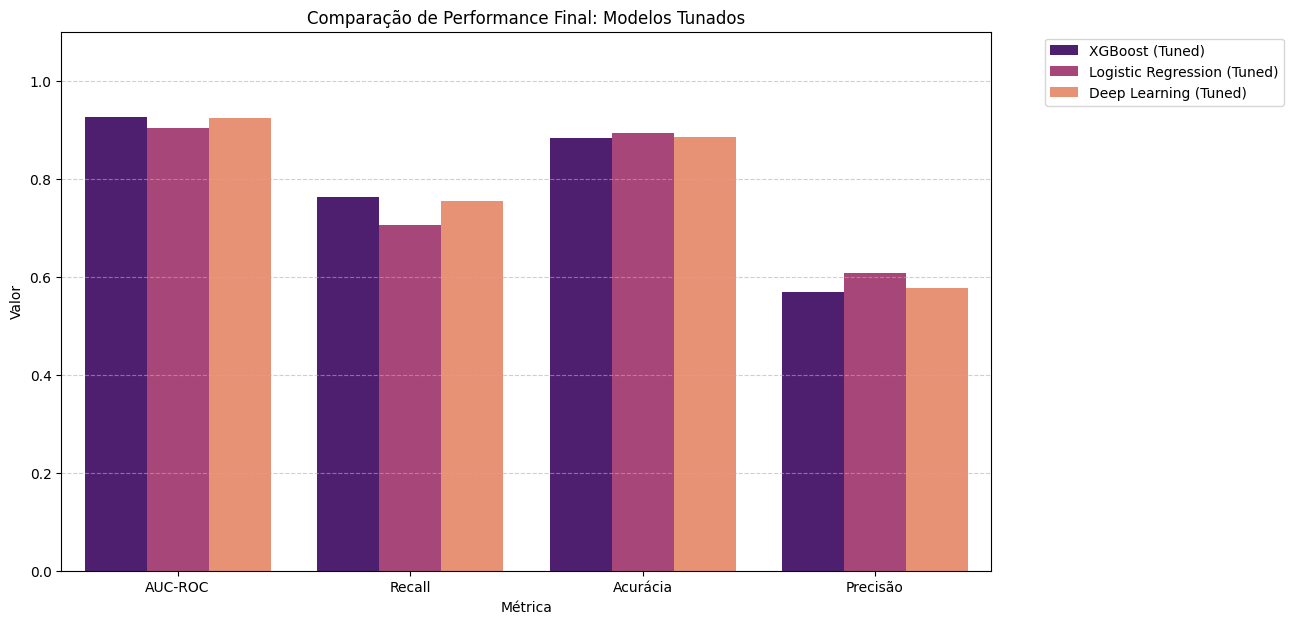

,Modelo,AUC-ROC,Recall,Acurácia,Precisão
0,XGBoost (Tuned),0.926451,0.762295,0.883558,0.568807
1,Logistic Regression (Tuned),0.904445,0.704918,0.892920,0.607774
2,Deep Learning (Tuned),0.923860,0.754098,0.885898,0.576803


In [41]:
resultados_finais = {
    'Modelo': ['XGBoost (Tuned)', 'Logistic Regression (Tuned)', 'Deep Learning (Tuned)'],
    'AUC-ROC': [auc_final, auc_lr, auc_f],
    'Recall': [rec_final, rec_lr, rec_f],
    'Acurácia': [acc_final, acc_lr, acc_f],
    'Precisão': [prec_final, prec_lr, prec_f]
}

df_finais = pd.DataFrame(resultados_finais)
df_melted_finais = df_finais.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted_finais, x='Métrica', y='Valor', hue='Modelo', palette='magma')
plt.title('Comparação de Performance Final: Modelos Tunados')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

display(df_finais)

##Resultados

###**Regressão Logística**:

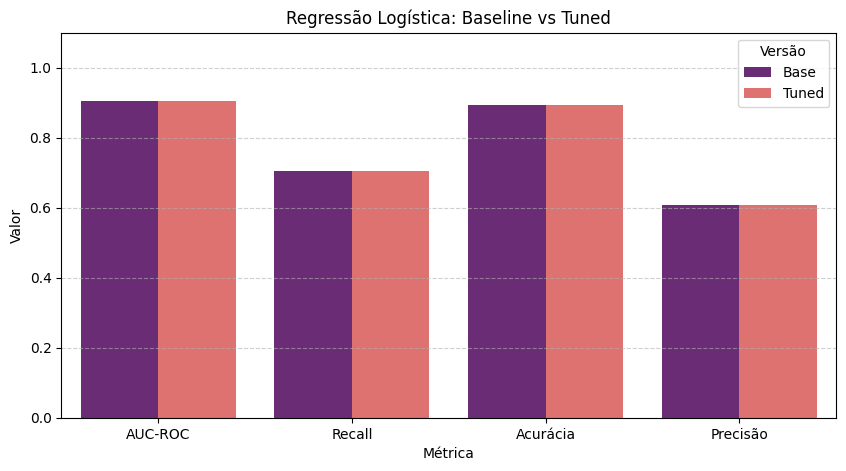

In [6]:
# dados comparativos Regressão Logística
lr_comp = pd.DataFrame({
    'Métrica': ['AUC-ROC', 'Recall', 'Acurácia', 'Precisão', 'AUC-ROC', 'Recall', 'Acurácia', 'Precisão'],
    'Valor': [0.9044, 0.7049, 0.8929, 0.6078, 0.9044, 0.7049, 0.8929, 0.6078,],
    'Versão': ['Base', 'Base', 'Base', 'Base', 'Tuned', 'Tuned', 'Tuned', 'Tuned']
})

plt.figure(figsize=(10, 5))
sns.barplot(data=lr_comp, x='Métrica', y='Valor', hue='Versão', palette='magma')
plt.title('Regressão Logística: Baseline vs Tuned')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Antes**: AUC 0.9044 | Recall 0.7049 | Precisão: 0.6078 | Acurácia: 0.8929

**Depois**: AUC 0.9044 | Recall 0.7049 | Precisão: 0.6078 | Acurácia: 0.8929

**O Veredito**: O modelo já havia batido no teto. Tunar hiperparâmetros com Optuna não trouxe melhorias, pois ela não consegue dobrar o espaço matemático para se ajustar a padrões complexos.

###**Deep Learning**:

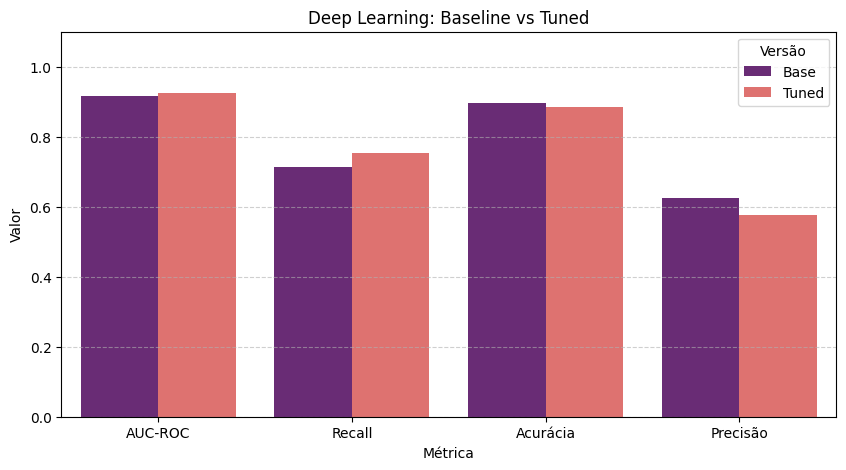

In [7]:
# dados comparativos Deep Learning
dl_comp = pd.DataFrame({
    'Métrica': ['AUC-ROC', 'Recall', 'Acurácia', 'Precisão', 'AUC-ROC', 'Recall', 'Acurácia', 'Precisão'],
    'Valor': [0.9174, 0.7131, 0.8976, 0.6237, 0.9238, 0.7540, 0.8859, 0.5768],
    'Versão': ['Base', 'Base', 'Base', 'Base', 'Tuned', 'Tuned', 'Tuned', 'Tuned']
})

plt.figure(figsize=(10, 5))
sns.barplot(data=dl_comp, x='Métrica', y='Valor', hue='Versão', palette='magma')
plt.title('Deep Learning: Baseline vs Tuned')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Antes**: AUC 0.9174 | Recall 0.7131 | Precisão: 0.6237 | Acurácia: 0.8976

**Depois**: AUC 0.9238 | Recall 0.7540 | Precisão: 0.5768 | Acurácia: 0.8859

**O Veredito**: O Optuna conseguiu esticar o Recall em 4%, fazendo a rede achar ainda mais compradores, sacrificando um pouco da Precisão (caiu de 62% para 57%). O Optuna priorizou o Recall, o que naturalmente aumenta o número de falsos positivos, reduzindo a precisão em troca de capturar mais compradores reais.

###**XGBoost**:

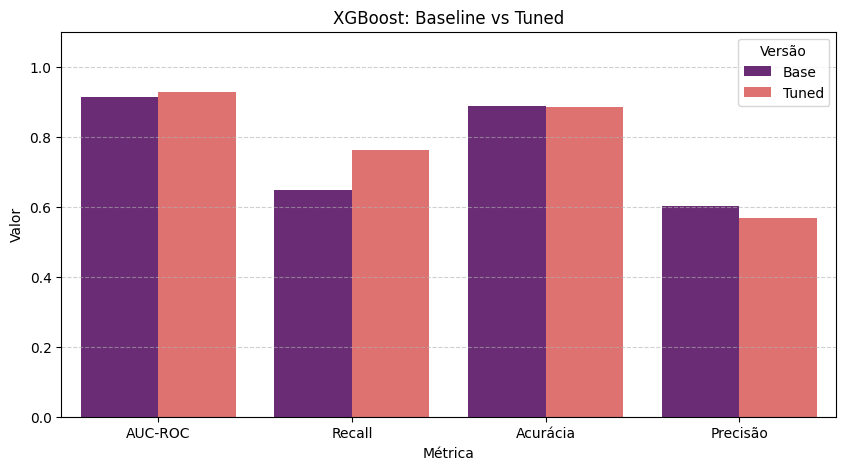

In [8]:
# dados comparativos XGBoost
xgb_comp = pd.DataFrame({
    'Métrica': ['AUC-ROC', 'Recall', 'Acurácia', 'Precisão', 'AUC-ROC', 'Recall', 'Acurácia', 'Precisão'],
    'Valor': [0.9134, 0.6475, 0.8888, 0.6031, 0.9264, 0.7622, 0.8836, 0.5688],
    'Versão': ['Base', 'Base', 'Base', 'Base', 'Tuned', 'Tuned', 'Tuned', 'Tuned']
})

plt.figure(figsize=(10, 5))
sns.barplot(data=xgb_comp, x='Métrica', y='Valor', hue='Versão', palette='magma')
plt.title('XGBoost: Baseline vs Tuned')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Antes**: AUC 0.9134 | Recall 0.6475 | Precisão: 0.6031 | Acurácia: 0.8888

**Depois**: AUC 0.9264 | Recall 0.7622 | Precisão: 0.5688 | Acurácia: 0.8836

**O Veredito**: O Optuna pegou um Recall que estava em 64% e o catapultou para 76.2%. Ele não só alcançou o Deep Learning, como o ultrapassou.

O XGBoost Tunado agora é o modelo que mais encontra compradores nesse e-commerce (maior Recall).

Assim como no Deep Learning, o ganho de Recall (de 64% para 76%) exigiu um trade-off, resultando na menor precisão entre os modelos tunados, mas entregando o melhor equilíbrio global (maior AUC: 0.9264).

## Escolha do Melhor Modelo:

Após a fase de experimentação e otimização com Optuna, o modelo selecionado para implantação é o **XGBoost Tunado**.

### **Por que o XGBoost?**

1.  **Maior Poder de Identificação (Recall: 76.2%)**: Em um e-commerce, o custo de perder uma venda (Falso Negativo) costuma ser maior do que o custo de uma campanha de marketing enviada a alguém que não vai comprar. O XGBoost foi o modelo que mais encontrou compradores reais.

2.  **Melhor Desempenho Global (AUC-ROC: 0.9264)**: Ele apresentou a melhor capacidade de distinguir entre compradores e não-compradores em todas as faixas de probabilidade.

3.  **Eficiência e Flexibilidade**: O XGBoost lida de forma nativa com dados desbalanceados através do parâmetro `scale_pos_weight` e gera um arquivo leve (`.json`), ideal para o deploy.

4.  **Superação do Deep Learning**: Embora as Redes Neurais sejam poderosas, para este conjunto específico de dados tabulares, o algoritmo de Gradient Boosting de Árvores mostrou-se mais robusto e eficiente após o ajuste fino, além de exigir um poder de processamento computacional menor.

###Salvando os melhores modelos

In [43]:
# salvando o modelo de Deep Learning Tunado
campeao_nn.save('deep_learning_tunado.keras')

# Salvando o modelo XGBoost Tunado
campeao_xgb.save_model('xgboost_tunado.json')

print("Modelos salvos com sucesso!")

Modelos salvos com sucesso!


In [44]:
# baixando os modelos
try:
    files.download('deep_learning_tunado.keras')
    files.download('xgboost_tunado.json')
except Exception as e:
    print(f"Erro ao iniciar download automático: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Explicando a IA com SHAP

In [9]:
# carregando o modelo para uso com SHAP
xgb_final = XGBClassifier()
xgb_final.load_model('xgboost_tunado.json')

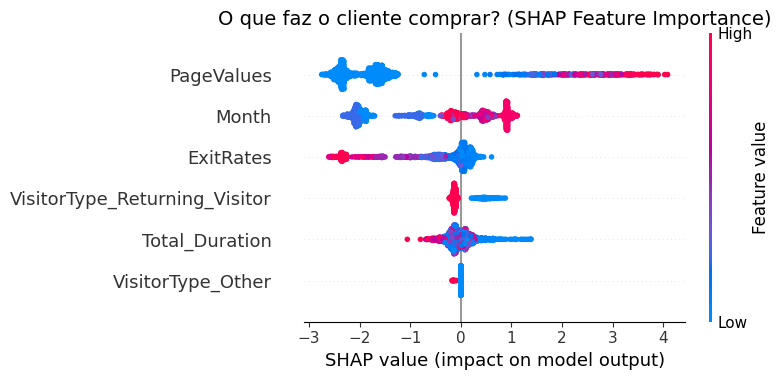

In [50]:
# inicializamos o explicador do SHAP focado em árvores (TreeExplainer)
explainer = shap.TreeExplainer(xgb_final)

# reconstruindo o DataFrame para o gráfico ficar com os nomes das colunas originais
X_val_df = pd.DataFrame(X_val_scaled, columns=X.columns)

# calculamos os valores SHAP
shap_values = explainer(X_val_df)

# gerando gráfico
plt.figure(figsize=(10, 6))
plt.title("O que faz o cliente comprar? (SHAP Feature Importance)", fontsize=14)

# o relatório final
shap.summary_plot(shap_values, X_val_df, plot_type="dot", show=False)

plt.tight_layout()
plt.show()

###Resultados:
A variável no topo absoluto é o Valor da Página.
* Page Values:
  * Significa que se o cliente visita páginas valiosas do site, a chance dele comprar explode.
* Month:
  * Dependendo do mês as chances de compra podem aumentar ou diminuir, como verificamos anteriormente o mês de novembro era o que mais influenciava, provavelmente por causa da Black Friday.
* ExitRates:
  * Se o cliente entra em páginas onde as pessoas costumam abandonar o site rapidamente (páginas chatas, quebradas ou confusas), a chance de venda morre.
* VisitorType_Returning_Visitor:
  * As bolinhas vermelhas significam True (É um cliente recorrente). Elas estão agrupadas na esquerda (Diminui a chance de compra). As bolinhas azuis False (É um cliente novo) estão puxando para a direita (Aumenta a chance de compra).

###Portanto:
O nosso modelo descobriu que para garantir uma venda, precisamos trazer tráfego novo (azul no VisitorType), engajá-los durante o fim do ano (vermelho no Month), direcioná-los rapidamente para as páginas de mais valor (vermelho no PageValues) e evitar a todo custo as páginas com alta taxa de abandono (vermelho no ExitRates).

##Resultados finais:

###Prevendo com dados que o modelo nunca viu

In [23]:
# fazendo as previsões finais nos dados que o modelo nunca viu (X_test_scaled)
y_pred_test = xgb_final.predict(X_test_scaled)
y_prob_test = xgb_final.predict_proba(X_test_scaled)[:, 1]

# calculando as 4 métricas
auc_test = roc_auc_score(y_test, y_prob_test)
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, zero_division=0)
rec_test = recall_score(y_test, y_pred_test)

# imprimindo as 4 métricas finais de produção
print(f"AUC-ROC: {auc_test:.4f} | Acurácia: {acc_test:.4f} | Precisão: {prec_test:.4f} | Recall: {rec_test:.4f} ")

# matriz de confusão para vermos exatamente quantos clientes acertamos e erramos
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_test))

AUC-ROC: 0.9294 | Acurácia: 0.8795 | Precisão: 0.5534 | Recall: 0.8074 
Matriz de Confusão:
[[1307  159]
 [  47  197]]


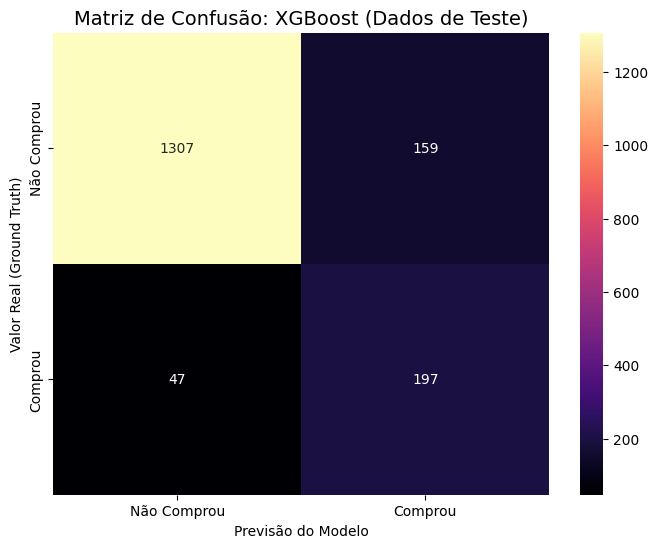

In [30]:
# criando a visualização da Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='magma',
            xticklabels=['Não Comprou', 'Comprou'],
            yticklabels=['Não Comprou', 'Comprou'])

plt.title('Matriz de Confusão: XGBoost (Dados de Teste)', fontsize=14)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.show()

Na Validação o Recall estava em 76%, o modelo não apenas não viciou (não deu overfitting), como ele performou ainda melhor nos dados de teste com um Recall de 80.7%. Ele consegue identificar com sucesso nossos compradores em potencial.

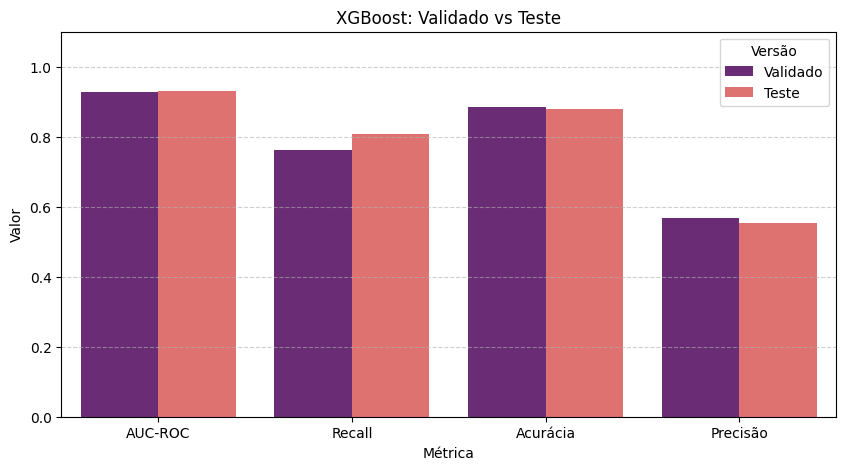

In [29]:
# dados comparativos XGBoost Validado vs Teste
xgb_final_df = pd.DataFrame({
    'Métrica': ['AUC-ROC', 'Recall', 'Acurácia', 'Precisão', 'AUC-ROC', 'Recall', 'Acurácia', 'Precisão'],
    'Valor': [0.9264, 0.7622, 0.8836, 0.5688, 0.9294, 0.8074 , 0.8795, 0.5534],
    'Versão': ['Validado', 'Validado', 'Validado', 'Validado', 'Teste', 'Teste', 'Teste', 'Teste']
})

plt.figure(figsize=(10, 5))
sns.barplot(data=xgb_final_df, x='Métrica', y='Valor', hue='Versão', palette='magma')
plt.title('XGBoost: Validado vs Teste')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###Ou seja:

Imagine que 1.710 clientes acabaram de passar pelo nosso site:
  * **Os 197** (Verdadeiros Positivos):
    O modelo identificou com sucesso 197 pessoas que estavam prontas para comprar. Nós demos um empurrãozinho (ex: um cupom na hora certa) e garantimos o faturamento.

  * **Os 1.307** (Verdadeiros Negativos):
  O modelo identificou perfeitamente os "curiosos" (vitrineiros) e decidiu não fazer nada. Poupamos dinheiro e não fomos chatos enviando e-mails inúteis.

  * **Os 159** (Falsos Positivos):
    O modelo achou que 159 pessoas iam comprar, mas elas não compraram. Nós mandamos um cupom de desconto à toa para eles. Qual o custo disso? Zero. É só um e-mail digital.

  * **Os 47** (Falsos Negativos):
    47 pessoas compraram, mas o modelo não percebeu, mas perder apenas 47 em um mar de 1.710 clientes é uma taxa de erro absurdamente baixa.

#**Concluindo**:
O algoritmo encontrou 80% dos nossos compradores escondidos na multidão e o custo disso foram apenas 159 cupons disparados no vazio. O modelo está pronto para o Deploy!